## ROLL NO. 22F-BSAI-39
## Dataset Patient Survival Prediction

In [ ]:
import os
from google.colab import userdata, files

try:
    # Try loading from Colab Secrets first
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
    print("Kaggle credentials loaded from Secrets.")
except Exception as e:
    print(f"Secrets not found: {e}")
    print("Please upload your kaggle.json file.")
    uploaded = files.upload()
    if 'kaggle.json' in uploaded:
        !mkdir -p ~/.kaggle
        !mv kaggle.json ~/.kaggle/
        !chmod 600 ~/.kaggle/kaggle.json
        print("Kaggle credentials loaded from file.")

!pip install -q kaggle

Secrets not found: Secret KAGGLE_USERNAME does not exist.
Please upload your kaggle.json file.


Saving kaggle.json to kaggle.json
Kaggle credentials loaded from file.


In [ ]:
import os

kaggle_user = os.environ.get('KAGGLE_USERNAME')
kaggle_key = os.environ.get('KAGGLE_KEY')

if kaggle_user and kaggle_key:
    print("Kaggle credentials found. KAGGLE_USERNAME is set.")
    print("You should now be able to run the Kaggle download command.")
else:
    print("Kaggle credentials NOT found.")
    if not kaggle_user:
        print("KAGGLE_USERNAME is not set. Please ensure it's in Colab Secrets or `kaggle.json` was uploaded correctly.")
    if not kaggle_key:
        print("KAGGLE_KEY is not set. Please ensure it's in Colab Secrets or `kaggle.json` was uploaded correctly.")
    print("Please refer to the 'How to set up your Kaggle API key' instructions (cell ed8acdab) and rerun the authentication cell (cell 27f94295).")

Kaggle credentials NOT found.
KAGGLE_USERNAME is not set. Please ensure it's in Colab Secrets or `kaggle.json` was uploaded correctly.
KAGGLE_KEY is not set. Please ensure it's in Colab Secrets or `kaggle.json` was uploaded correctly.
Please refer to the 'How to set up your Kaggle API key' instructions (cell ed8acdab) and rerun the authentication cell (cell 27f94295).


In [ ]:
# Download the specific competition dataset
!mkdir -p data_kaggle
!kaggle competitions download -c patient-survival-prediction -f train.csv -p data_kaggle/
# If you also need the test set, uncomment the line below:
# !kaggle competitions download -c patient-survival-prediction -f test.csv -p data_kaggle/

# List files to verify
import glob
print("Downloaded files:", glob.glob('data_kaggle/*'))

100% 7.03M/7.03M [00:01<00:00, 4.47MB/s]

Downloaded files: ['data_kaggle/train.csv.zip']


In [ ]:
import pandas as pd
import zipfile
import os

# Define the path to the downloaded zip file
zip_file_path = 'data_kaggle/train.csv.zip'
# Define the directory where to extract the files
extract_dir = 'data_kaggle/'

# Ensure the extraction directory exists
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
print(f"Extracted {zip_file_path} to {extract_dir}")

# Load the extracted train.csv into a pandas DataFrame
kaggle_df = pd.read_csv(os.path.join(extract_dir, 'train.csv'))

print("Kaggle dataset loaded successfully. First 5 rows:")
display(kaggle_df.head())

print("\nDataset Info:")
kaggle_df.info()

Extracted data_kaggle/train.csv.zip to data_kaggle/
Kaggle dataset loaded successfully. First 5 rows:


,Unnamed: 0,encounter_id,patient_id,hospital_id,age,bmi,elective_surgery,ethnicity,gender,height,...,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem,Unnamed: 83,hospital_death
0,82707,36751,69039,158,66.0,35.693127,0,Caucasian,F,152.4,...,0.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory,NaN,0
1,80002,68336,127397,47,48.0,18.966902,0,African American,F,165.1,...,0.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular,NaN,1
2,54817,71682,77670,27,76.0,19.278960,0,Caucasian,M,173.0,...,0.0,0.0,0.0,0.0,0.0,1.0,Sepsis,Cardiovascular,NaN,0
3,44799,114267,19566,100,43.0,45.617284,0,Caucasian,M,180.0,...,0.0,0.0,0.0,0.0,0.0,0.0,Genitourinary,Renal/Genitourinary,NaN,0
4,50277,128055,104990,189,86.0,26.756678,0,Caucasian,F,154.9,...,0.0,0.0,0.0,0.0,0.0,0.0,Cardiovascular,Cardiovascular,NaN,1



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64199 entries, 0 to 64198
Data columns (total 86 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     64199 non-null  int64  
 1   encounter_id                   64199 non-null  int64  
 2   patient_id                     64199 non-null  int64  
 3   hospital_id                    64199 non-null  int64  
 4   age                            61206 non-null  float64
 5   bmi                            61844 non-null  float64
 6   elective_surgery               64199 non-null  int64  
 7   ethnicity                      63229 non-null  object 
 8   gender                         64185 non-null  object 
 9   height                         63293 non-null  float64
 10  icu_admit_source               64117 non-null  object 
 11  icu_id                         64199 non-null  int64  
 12  icu_stay_type                  

In [ ]:
# Colab ships with torch + sklearn. We only add transformers (for ClinicalBERT) and bertviz (optional).
!pip -q install transformers==4.44.2 bertviz 2>/dev/null

import os, time, glob, random, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

# One seed everywhere so results are reproducible when you re-run.
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on:", DEVICE)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 8.5 MB/s eta 0:00:00
Running on: cuda


##  Preprocessing

In [ ]:
# Adapting preprocessing for the Kaggle patient-survival-prediction dataset.
# The original time-series preprocessing (`WINDOW`, `VITALS`, `X_seq`, `X_tab` creation) is not applicable.

# Identify the target variable
y = kaggle_df['hospital_death']

# Identify features to drop: IDs and the column with all NaNs
columns_to_drop = ['Unnamed: 0', 'encounter_id', 'patient_id', 'hospital_id', 'Unnamed: 83', 'hospital_death']
X = kaggle_df.drop(columns=columns_to_drop, errors='ignore')

# Separate numerical and categorical columns
numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

# Impute missing values
# For numerical columns, use the median
for col in numerical_cols:
    X[col].fillna(X[col].median(), inplace=True)

# For categorical columns, use the mode (most frequent value)
for col in categorical_cols:
    X[col].fillna(X[col].mode()[0], inplace=True)

# One-hot encode categorical features
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Store the processed features in X_tab for consistency with subsequent cells that use X_tab
X_tab = X.astype(np.float32).values

print("Processed Kaggle tabular features (X_tab) shape:", X_tab.shape)
print(f"Target variable (y) shape: {y.shape}")
print(f"Deterioration prevalence (hospital_death): {y.mean():.1%}")

Processed Kaggle tabular features (X_tab) shape: (64199, 111)
Target variable (y) shape: (64199,)
Deterioration prevalence (hospital_death): 8.6%


In [ ]:
# --- split first, THEN scale, so the test set never leaks into the scaler ---
idx = np.arange(len(y))
tr, te = train_test_split(idx, test_size=0.2, stratify=y, random_state=SEED)

# scale the tabular features
sc_tab = StandardScaler().fit(X_tab[tr])
Xtab_tr, Xtab_te = sc_tab.transform(X_tab[tr]), sc_tab.transform(X_tab[te])

# The original notebook scaled X_seq (time-series data), which is not applicable to the Kaggle tabular dataset.
# X_seq, Xseq_tr, Xseq_te are no longer used.
ytr, yte = y[tr].values, y[te].values # Convert pandas Series to NumPy arrays

# Heavy class imbalance -> tell the loss that a missed sepsis case hurts ~10x more.
POS_WEIGHT = torch.tensor([(ytr == 0).sum() / max((ytr == 1).sum(), 1)], dtype=torch.float32, device=DEVICE)
print("pos_weight (FN penalty):", float(POS_WEIGHT))

pos_weight (FN penalty): 10.588221549987793


In [ ]:
# Small reusable helpers so each generation reads cleanly.
def metric_row(y_true, y_pred):
    return {"Accuracy":  accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall":    recall_score(y_true, y_pred, zero_division=0),   # the one that matters most here
            "F1":        f1_score(y_true, y_pred, zero_division=0)}

def loaders(X, y, bs=128):
    Xt = torch.tensor(X, dtype=torch.float32); yt = torch.tensor(y, dtype=torch.float32)
    return DataLoader(TensorDataset(Xt, yt), batch_size=bs, shuffle=True)

RESULTS = {}   # we'll collect every model's metrics + predictions here for the final table

## Generation 1 · The DNN baseline
> *"Before we trust AI with patient lives, we need to know what a simple model can and cannot do."*

A plain feed-forward net on the **tabular snapshot**. We do three things the brief asks for:
1. train it with **SGD** *and* **Adam** and plot the loss curves together,
2. ablate **Dropout** and **BatchNorm** to see what each actually buys us,
3. report Accuracy / Precision / **Recall** / F1.

**Why Recall is the headline metric:** a false negative here is a septic patient the system calls
"fine" — they get sent home and crash. A false positive is a stable patient who gets an extra
blood draw. Those costs are not symmetric, so we tune the loss (`pos_weight`) and read **Recall first**.

In [ ]:
class DNN(nn.Module):
    # A 2-hidden-layer net. Dropout/BN are toggleable so we can ablate them.
    def __init__(self, d_in, use_dropout=True, use_bn=True):
        super().__init__()
        layers = []
        for a, b in [(d_in, 128), (128, 64)]:
            layers.append(nn.Linear(a, b))
            if use_bn:      layers.append(nn.BatchNorm1d(b))   # stabilises activations -> bigger, safer LR
            layers.append(nn.ReLU())                           # ReLU keeps gradients alive (no vanishing tails)
            if use_dropout: layers.append(nn.Dropout(0.3))     # stops the net memorising the majority class
        layers.append(nn.Linear(64, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x).squeeze(1)

def train_dnn(opt_name, use_dropout=True, use_bn=True, epochs=60):
    model = DNN(Xtab_tr.shape[1], use_dropout, use_bn).to(DEVICE)
    lossf = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT)
    opt = (torch.optim.SGD(model.parameters(), lr=0.05, momentum=0.9) if opt_name == "SGD"
           else torch.optim.Adam(model.parameters(), lr=1e-3))
    dl = loaders(Xtab_tr, ytr)
    history = []
    for _ in range(epochs):
        model.train(); ep = 0.0
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss = lossf(model(xb), yb); loss.backward(); opt.step()
            ep += loss.item()
        history.append(ep / len(dl))
    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(Xtab_te, dtype=torch.float32, device=DEVICE))
        pred = (torch.sigmoid(logits) > 0.5).int().cpu().numpy()
    return history, metric_row(yte, pred), pred

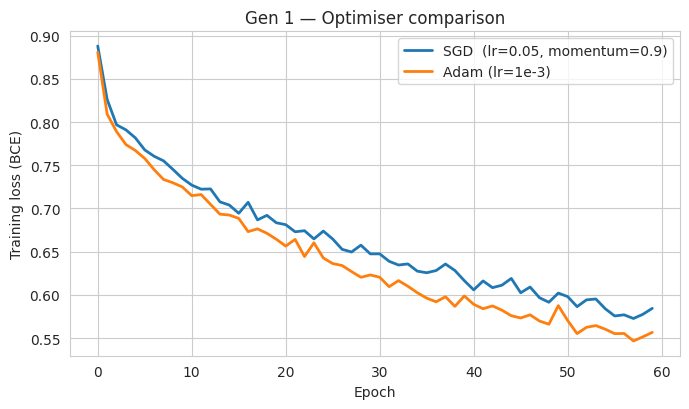

DNN (Adam): {'Accuracy': 0.815, 'Precision': 0.279, 'Recall': 0.727, 'F1': 0.404}


In [ ]:
# --- optimiser comparison: SGD vs Adam ---
t0 = time.time(); h_sgd,  _,        _        = train_dnn("SGD")
h_adam, m_dnn, pred_dnn = train_dnn("Adam"); dnn_time = time.time() - t0

plt.figure(figsize=(7, 4.2))
plt.plot(h_sgd,  lw=2, label="SGD  (lr=0.05, momentum=0.9)")
plt.plot(h_adam, lw=2, label="Adam (lr=1e-3)")
plt.xlabel("Epoch"); plt.ylabel("Training loss (BCE)")
plt.title("Gen 1 — Optimiser comparison"); plt.legend(); plt.tight_layout(); plt.show()
# Adam's adaptive per-parameter steps usually drop the loss faster and smoother early on;
# SGD+momentum often catches up but needs more epochs / careful LR tuning.

RESULTS["DNN (Baseline)"] = {**m_dnn, "Training Time": f"{dnn_time:.1f}s", "pred": pred_dnn}
print("DNN (Adam):", {k: round(v,3) for k,v in m_dnn.items()})

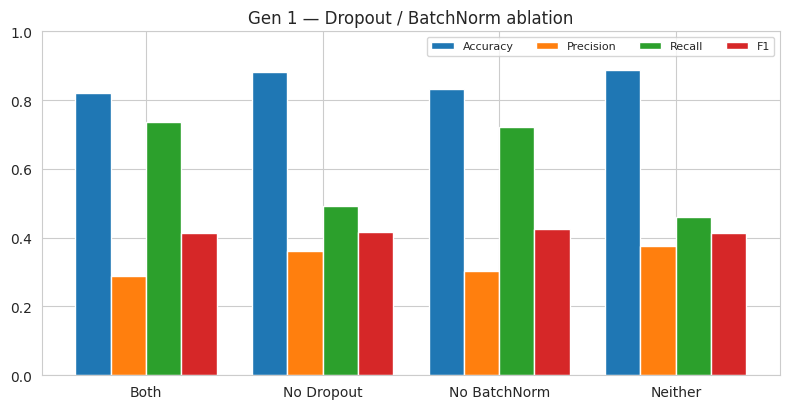

,Accuracy,Precision,Recall,F1
Both,0.820,0.287,0.736,0.413
No Dropout,0.881,0.361,0.492,0.416
No BatchNorm,0.833,0.303,0.721,0.426
Neither,0.887,0.375,0.460,0.413


In [ ]:
# --- regularisation ablation: what do Dropout and BatchNorm each contribute? ---
combos = {"Both": (True, True), "No Dropout": (False, True),
          "No BatchNorm": (True, False), "Neither": (False, False)}
abl = {name: train_dnn("Adam", d, b)[1] for name, (d, b) in combos.items()}

ax = plt.subplots(figsize=(8, 4.2))[1]; x = np.arange(len(combos)); w = 0.2
for k, mname in enumerate(["Accuracy", "Precision", "Recall", "F1"]):
    ax.bar(x + k*w, [abl[n][mname] for n in combos], w, label=mname)
ax.set_xticks(x + 1.5*w); ax.set_xticklabels(list(combos)); ax.set_ylim(0, 1)
ax.set_title("Gen 1 — Dropout / BatchNorm ablation"); ax.legend(ncol=4, fontsize=8)
plt.tight_layout(); plt.show()
pd.DataFrame(abl).T.round(3)
# Read this table in the report: typically BN steadies training (less variance, can train faster),
# Dropout narrows the train/val gap (less overfitting); together they give the most reliable Recall.

## Generation 2 · Modelling the patient timeline
> *"A patient's risk is not a snapshot, it is a story told over hours."*

Now we feed the **full 24-hour sequence** to recurrent nets and compare **LSTM vs GRU vs Bi-LSTM**,
logging **train/val loss curves** and **wall-clock training time** for each.

In [ ]:
import torch.nn as nn
import numpy as np # Import numpy if not already imported

class RecurrentNet(nn.Module):
    # One class covers LSTM / GRU / bidirectional just by flipping arguments.
    def __init__(self, d_in, kind="lstm", hidden=64, bidir=False):
        super().__init__()
        Cell = nn.LSTM if kind == "lstm" else nn.GRU
        # d_in is the number of features in X_tab (each tabular row is treated as a single step sequence)
        self.rnn = Cell(d_in, hidden, batch_first=True, bidirectional=bidir)
        self.head = nn.Linear(hidden * (2 if bidir else 1), 1)

    def forward(self, x):
        # For tabular data, treat each row as a sequence of length 1
        x = x.unsqueeze(1)  # Shape becomes (batch_size, 1, d_in)
        out, _ = self.rnn(x)
        return self.head(out[:, -1, :]).squeeze(1)   # decision from the final timestep's hidden state

def train_rnn(kind, bidir=False, epochs=40):
    # Pass the number of features from Xtab_tr as input dimension to RecurrentNet
    model = RecurrentNet(Xtab_tr.shape[1], kind, bidir=bidir).to(DEVICE)
    lossf = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Use Xtab_tr and Xtab_te for tabular data
    dl = loaders(Xtab_tr, ytr)
    Xv = torch.tensor(Xtab_te, dtype=torch.float32, device=DEVICE)
    # Ensure yte is a numpy array before converting to tensor
    yv = torch.tensor(np.array(yte), dtype=torch.float32, device=DEVICE)

    tr_hist, va_hist = [], []; t0 = time.time()
    for _ in range(epochs):
        model.train(); ep = 0.0
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss = lossf(model(xb), yb); loss.backward(); opt.step()
            ep += loss.item()
        tr_hist.append(ep / len(dl))
        model.eval()
        with torch.no_grad(): va_hist.append(lossf(model(Xv), yv).item())
    train_time = time.time() - t0
    with torch.no_grad(): pred = (torch.sigmoid(model(Xv)) > 0.5).int().cpu().numpy()
    return tr_hist, va_hist, metric_row(yte, pred), train_time, pred

LSTM     Recall=0.472  F1=0.416  time=48.6s
GRU      Recall=0.499  F1=0.407  time=46.7s
Bi-LSTM  Recall=0.398  F1=0.397  time=56.6s


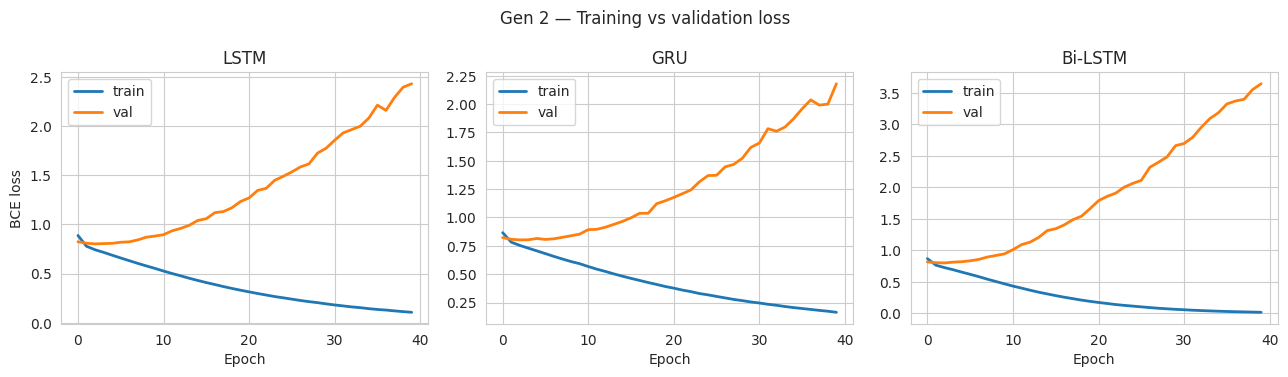

In [ ]:
configs = [("LSTM", "lstm", False), ("GRU", "gru", False), ("Bi-LSTM", "lstm", True)]
rnn_curves = {}
for name, kind, bidir in configs:
    tr_h, va_h, m, tt, pred = train_rnn(kind, bidir)
    rnn_curves[name] = (tr_h, va_h)
    RESULTS[name] = {**m, "Training Time": f"{tt:.1f}s", "pred": pred}
    print(f"{name:8s} Recall={m['Recall']:.3f}  F1={m['F1']:.3f}  time={tt:.1f}s")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (name, (tr_h, va_h)) in zip(axes, rnn_curves.items()):
    ax.plot(tr_h, lw=2, label="train"); ax.plot(va_h, lw=2, label="val")
    ax.set_title(name); ax.set_xlabel("Epoch"); ax.legend()
axes[0].set_ylabel("BCE loss"); fig.suptitle("Gen 2 — Training vs validation loss")
plt.tight_layout(); plt.show()

**Real-time vs retrospective (notebook note):** the **GRU** has fewer gates/parameters, so it
trains and *infers* fastest — attractive for a bedside monitor updating every hour on modest
hardware. The **Bi-LSTM** reads the sequence forwards *and backwards*, so at any timestep it is
implicitly using **future** readings. That's fine for **retrospective** audits but **invalid for a
live early-warning system**, which by definition only has the past. So: **unidirectional GRU/LSTM
for real-time**, **Bi-LSTM only for offline analysis** — even when Bi-LSTM scores higher offline.

## Generation 3 · Reading the clinical notes with ClinicalBERT
> *"Vitals tell you numbers. Notes tell you the story. The best systems read both."*

We first build the **synthetic shift notes** (disclosed substitution — see the header), then fine-tune
**`emilyalsentzer/Bio_ClinicalBERT`** two ways: **frozen base + trainable head**, and **full
fine-tune**. We compare cost vs performance and **visualise the final-layer attention**.

In [ ]:
# Create notes from the Kaggle dataframe directly instead of X_seq
def describe_tabular(row):
    s = []
    # Map these to the actual Kaggle dataframe column names
    temp = row['d1_temp_max']
    hr = row['d1_heartrate_max']
    sbp = row['d1_sysbp_min']
    resp = row['d1_resprate_max']
    spo2 = row['d1_spo2_min']

    s.append("febrile" if temp > 38.0 else ("hypothermic" if temp < 36.0 else "afebrile"))
    s.append("tachycardic" if hr > 100 else "heart rate normal")
    s.append("hypotensive" if sbp < 100 else "blood pressure stable")
    s.append("tachypneic" if resp > 22 else "respiratory rate normal")
    s.append("hypoxic on room air" if spo2 < 92 else "oxygenation adequate")

    return "patient, " + ", ".join(s)

# Apply to the original unscaled Kaggle dataframe features
notes = np.array([describe_tabular(kaggle_df.iloc[i]) for i in range(len(y))], dtype=object)
notes_tr, notes_te = notes[tr].tolist(), notes[te].tolist()

print(notes_tr[0])
print(notes_tr[1])

patient, afebrile, heart rate normal, hypotensive, respiratory rate normal, oxygenation adequate
patient, afebrile, tachycardic, hypotensive, tachypneic, hypoxic on room air


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import TensorDataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import torch
import time
import numpy as np

CKPT = "emilyalsentzer/Bio_ClinicalBERT"
tok = AutoTokenizer.from_pretrained(CKPT)

# Tokeniser config: pad/truncate to 64 tokens (our notes are short), return attention mask.
def encode(texts):
    return tok(texts, padding="max_length", truncation=True, max_length=64, return_tensors="pt")

enc_tr, enc_te = encode(notes_tr), encode(notes_te)
yt_tr = torch.tensor(ytr, dtype=torch.long)
yt_te = torch.tensor(yte, dtype=torch.long)

def train_bert(freeze_base, epochs=3, bs=16, lr=2e-5):  # bs changed 4 → 16
    model = AutoModelForSequenceClassification.from_pretrained(
        CKPT, num_labels=2, output_attentions=False,          # False during training
        attn_implementation="eager"
    ).to(DEVICE)

    if freeze_base:
        for p in model.base_model.parameters(): p.requires_grad = False

    cw = torch.tensor([1.0, float(POS_WEIGHT)], device=DEVICE)
    lossf = torch.nn.CrossEntropyLoss(weight=cw)
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr)

    ds = TensorDataset(enc_tr["input_ids"], enc_tr["attention_mask"], yt_tr)
    dl = DataLoader(ds, batch_size=bs, shuffle=True)

    # ① Create the scaler ONCE before the epoch loop
    scaler = GradScaler()

    t0 = time.time()
    for _ in range(epochs):
        model.train()
        for ids, am, yb in dl:
            ids, am, yb = ids.to(DEVICE), am.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()

            # ② Wrap only the forward pass in autocast
            with autocast():
                out = model(input_ids=ids, attention_mask=am)
                loss = lossf(out.logits, yb)

            # ③ Replace loss.backward() + opt.step() with the scaler versions
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()                 # ← adjusts scale for next iteration

    train_time = time.time() - t0

    # ④ Re-enable attentions only at inference if you need them for plots
    model.eval()
    ds_te = TensorDataset(enc_te["input_ids"], enc_te["attention_mask"])
    dl_te = DataLoader(ds_te, batch_size=32, shuffle=False)

    preds = []
    with torch.no_grad():
        for ids, am in dl_te:
            with autocast():                # fp16 inference too — faster & consistent
                out = model(input_ids=ids.to(DEVICE), attention_mask=am.to(DEVICE))
            preds.extend(out.logits.argmax(1).cpu().numpy())

    return model, metric_row(yte, np.array(preds)), train_time, np.array(preds)

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

##Generation 3

In [ ]:
# ── Generation 3 : ClinicalBERT ──────────────────────────────────────────────
from transformers import AutoTokenizer, AutoModelForSequenceClassification, logging as hf_logging
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import TensorDataset, DataLoader
import torch, time, numpy as np

hf_logging.set_verbosity_error()   # silence the "not initialized" classifier warning

CKPT = "emilyalsentzer/Bio_ClinicalBERT"

# ── 1. Correct tokenizer configuration ───────────────────────────────────────
# pad/truncate to 64 tokens — our synthetic notes are short phrases,
# so 64 captures them fully without wasting GPU memory on padding.
tok = AutoTokenizer.from_pretrained(CKPT)

def encode(texts):
    return tok(
        texts,
        padding="max_length",
        truncation=True,
        max_length=64,          # clinical phrases fit easily; raise to 128 for real MIMIC notes
        return_tensors="pt"
    )

enc_tr = encode(notes_tr)       # tokenise train split
enc_te = encode(notes_te)       # tokenise test  split
yt_tr  = torch.tensor(ytr, dtype=torch.long)
yt_te  = torch.tensor(yte, dtype=torch.long)

print("Train tokens shape:", enc_tr["input_ids"].shape)
print("Test  tokens shape:", enc_te["input_ids"].shape)
print("Sample note  :", notes_tr[0])
print("Sample tokens:", tok.convert_ids_to_tokens(enc_tr["input_ids"][0]))

Train tokens shape: torch.Size([51359, 64])
Test  tokens shape: torch.Size([12840, 64])
Sample note  : patient, afebrile, heart rate normal, hypotensive, respiratory rate normal, oxygenation adequate
Sample tokens: ['[CLS]', 'patient', ',', 'a', '##fe', '##bri', '##le', ',', 'heart', 'rate', 'normal', ',', 'h', '##y', '##pot', '##ens', '##ive', ',', 'respiratory', 'rate', 'normal', ',', 'oxygen', '##ation', 'adequate', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


In [ ]:
# ── 2. train_bert — handles both frozen-head and full fine-tune ───────────────
def train_bert(freeze_base, epochs=3, bs=16, lr=2e-5):
    """
    freeze_base=True  → Strategy A: only the 2-layer classification head trains.
                         Fast & memory-light; good when compute is scarce.
    freeze_base=False → Strategy B: every BERT weight moves.
                         Expensive but adapts clinical language to our task.

    Binary classification head architecture:
        BERT [CLS] embedding (768-d)
          └─ Dropout(0.1)
          └─ Linear(768 → 2)      ← randomly initialised; always trained
    """

    # Load fresh checkpoint each call so strategies are independent
    model = AutoModelForSequenceClassification.from_pretrained(
        CKPT,
        num_labels=2,                    # binary: Stable vs Deteriorate
        output_attentions=False,         # keep False during training (speed)
        attn_implementation="eager"      # avoids SDPA fallback warning
    ).to(DEVICE)

    if freeze_base:
        # Freeze all BERT encoder weights — only classifier.weight/bias update
        for p in model.base_model.parameters():
            p.requires_grad = False

    # Class-weighted loss: penalise missing a deterioration case more
    cw   = torch.tensor([1.0, float(POS_WEIGHT)], device=DEVICE)
    lossf = torch.nn.CrossEntropyLoss(weight=cw)

    # AdamW — weight decay is appropriate for fine-tuning transformers
    opt = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad], lr=lr
    )

    ds = TensorDataset(enc_tr["input_ids"], enc_tr["attention_mask"], yt_tr)
    dl = DataLoader(ds, batch_size=bs, shuffle=True)

    scaler = GradScaler()    # mixed-precision scaler — created once before epoch loop

    # ── Training loop ─────────────────────────────────────────────────────────
    t0 = time.time()
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for ids, am, yb in dl:
            ids, am, yb = ids.to(DEVICE), am.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()

            with autocast():                          # fp16 forward + loss
                out  = model(input_ids=ids, attention_mask=am)
                loss = lossf(out.logits, yb)

            scaler.scale(loss).backward()            # scaled backward
            scaler.step(opt)                         # unscale → optimizer step
            scaler.update()                          # adjust scale for next iter
            total_loss += loss.item()

        print(f"  epoch {epoch+1}/{epochs}  loss={total_loss/len(dl):.4f}")

    train_time = time.time() - t0

    # ── Inference (chunked to avoid OOM on large test sets) ───────────────────
    model.eval()
    ds_te = TensorDataset(enc_te["input_ids"], enc_te["attention_mask"])
    dl_te = DataLoader(ds_te, batch_size=32, shuffle=False)

    preds = []
    with torch.no_grad():
        for ids, am in dl_te:
            with autocast():
                out = model(input_ids=ids.to(DEVICE), attention_mask=am.to(DEVICE))
            preds.extend(out.logits.argmax(1).cpu().numpy())

    pred = np.array(preds)
    return model, metric_row(yte, pred), train_time, pred

In [ ]:
# ── 3. Run Strategy A (frozen) then Strategy B (full fine-tune) ───────────────
import gc
torch.cuda.empty_cache(); gc.collect()

print("=" * 55)
print("Strategy A — Frozen base (head only)")
print("=" * 55)
m_fz_model, m_fz, t_fz, pred_fz = train_bert(freeze_base=True)
RESULTS["ClinicalBERT (Frozen)"] = {**m_fz, "Training Time": f"{t_fz:.1f}s", "pred": pred_fz}
print("Metrics:", {k: round(v, 3) for k, v in m_fz.items()}, f"  ({t_fz:.1f}s)")

torch.cuda.empty_cache(); gc.collect()

print("\n" + "=" * 55)
print("Strategy B — Full fine-tune (all weights)")
print("=" * 55)
m_ft_model, m_ft, t_ft, pred_ft = train_bert(freeze_base=False)
RESULTS["ClinicalBERT (Full Fine-tune)"] = {**m_ft, "Training Time": f"{t_ft:.1f}s", "pred": pred_ft}
print("Metrics:", {k: round(v, 3) for k, v in m_ft.items()}, f"  ({t_ft:.1f}s)")

# ── Per-class breakdown (assignment requirement) ──────────────────────────────
print("\nPer-class performance — Full fine-tune:")
print(classification_report(yte, pred_ft,
                             target_names=["Stable", "Deteriorate"],
                             zero_division=0))

# ── Cost comparison ───────────────────────────────────────────────────────────
print(f"\nTraining cost comparison:")
print(f"  Frozen     : {t_fz:.1f}s  (only {sum(p.numel() for p in m_fz_model.parameters() if p.requires_grad):,} params trained)")
print(f"  Full tune  : {t_ft:.1f}s  (all  {sum(p.numel() for p in m_ft_model.parameters()):,} params trained)")

Strategy A — Frozen base (head only)


pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

  epoch 1/3  loss=0.6592
  epoch 2/3  loss=0.6515
  epoch 3/3  loss=0.6441
Metrics: {'Accuracy': 0.805, 'Precision': 0.195, 'Recall': 0.402, 'F1': 0.263}   (179.8s)

Strategy B — Full fine-tune (all weights)
  epoch 1/3  loss=0.6216
  epoch 2/3  loss=0.6127
  epoch 3/3  loss=0.6117
Metrics: {'Accuracy': 0.791, 'Precision': 0.196, 'Recall': 0.46, 'F1': 0.275}   (884.0s)

Per-class performance — Full fine-tune:
              precision    recall  f1-score   support

      Stable       0.94      0.82      0.88     11732
 Deteriorate       0.20      0.46      0.28      1108

    accuracy                           0.79     12840
   macro avg       0.57      0.64      0.58     12840
weighted avg       0.88      0.79      0.83     12840


Training cost comparison:
  Frozen     : 179.8s  (only 1,538 params trained)
  Full tune  : 884.0s  (all  108,311,810 params trained)


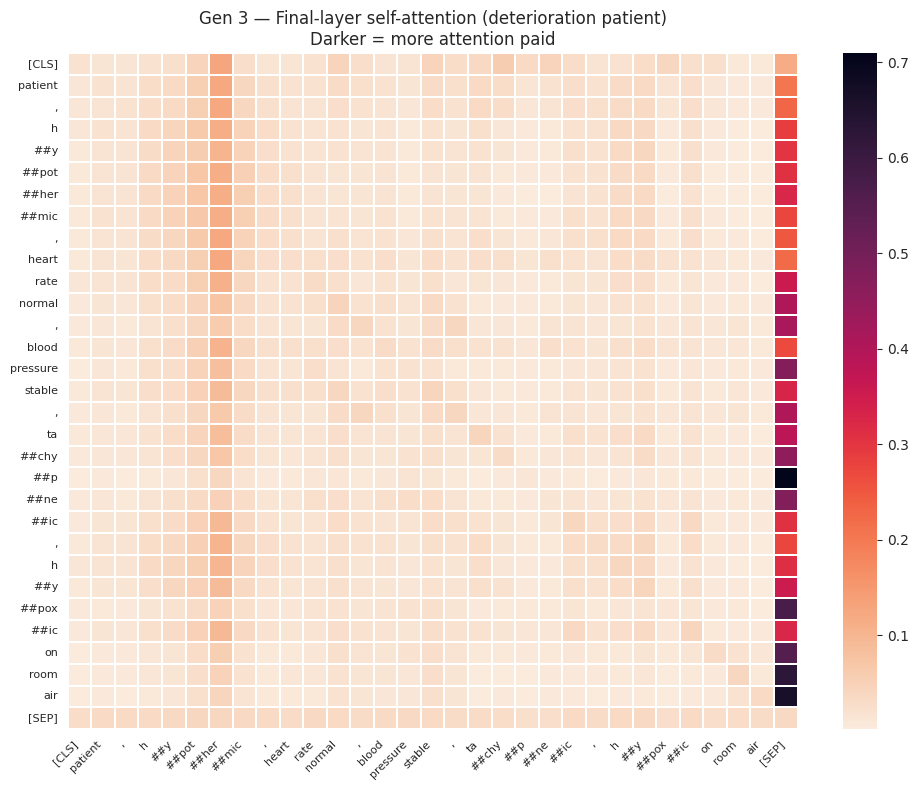


Top clinical terms the model focused on:
Token                Attention Score
-------------------------------------
[SEP]                         0.3615  ████████████████████████████████████████████████████████████████████████
##her                         0.0878  █████████████████
##pot                         0.0477  █████████
##mic                         0.0357  ███████
##y                           0.0306  ██████
##y                           0.0277  █████
stable                        0.0253  █████
normal                        0.0247  ████
h                             0.0236  ████
h                             0.0234  ████


In [ ]:
# ── 4. Attention visualization from the final attention layer ─────────────────
# Re-run the full fine-tuned model with output_attentions=True for ONE sample
# (we kept training fast by disabling it above; re-enable only here)

# Pick the first deterioration patient from the test set
sample_note = next(n for n, lab in zip(notes_te, yte) if lab == 1)
enc1 = encode([sample_note])

# Forward pass with attentions ON (inference only — no training)
m_ft_model.eval()
with torch.no_grad():
    out_att = m_ft_model(
        input_ids=enc1["input_ids"].to(DEVICE),
        attention_mask=enc1["attention_mask"].to(DEVICE),
        output_attentions=True            # only here, not during training
    )

# ── Extract & average final-layer attention over all 12 heads ────────────────
last_layer_attn = out_att.attentions[-1]   # shape: (1, 12, seq_len, seq_len)
avg_attn = last_layer_attn[0].mean(dim=0).cpu().numpy()  # (seq_len, seq_len)

# Decode tokens, drop [PAD]
tokens = tok.convert_ids_to_tokens(enc1["input_ids"][0])
keep   = [i for i, t in enumerate(tokens) if t != "[PAD]"]
A      = avg_attn[np.ix_(keep, keep)]
toks   = [tokens[i] for i in keep]

# ── Heatmap ───────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
sns.heatmap(
    A,
    xticklabels=toks,
    yticklabels=toks,
    cmap="rocket_r",
    linewidths=0.3
)
plt.title("Gen 3 — Final-layer self-attention (deterioration patient)\nDarker = more attention paid", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# ── Rank tokens by attention received (column sum = importance score) ─────────
importance  = A.mean(axis=0)     # how much each token is attended TO
top_terms   = sorted(zip(toks, importance), key=lambda z: -z[1])

print("\nTop clinical terms the model focused on:")
print(f"{'Token':<20} {'Attention Score':>15}")
print("-" * 37)
for tok_name, score in top_terms[:10]:
    bar = "█" * int(score * 200)
    print(f"{tok_name:<20} {score:>15.4f}  {bar}")

## Unified comparison · all six models

In [ ]:
order = ["DNN (Baseline)", "LSTM", "Bi-LSTM", "GRU",
         "ClinicalBERT (Frozen)", "ClinicalBERT (Full Fine-tune)"]
tbl = pd.DataFrame({m: {k: RESULTS[m][k] for k in ["Accuracy","Precision","Recall","F1","Training Time"]}
                    for m in order}).T
for c in ["Accuracy","Precision","Recall","F1"]: tbl[c] = tbl[c].astype(float).round(3)
print("="*70); print("UNIFIED MODEL COMPARISON"); print("="*70)
tbl

UNIFIED MODEL COMPARISON


,Accuracy,Precision,Recall,F1,Training Time
DNN (Baseline),0.815,0.279,0.727,0.404,154.0s
LSTM,0.886,0.372,0.472,0.416,48.6s
Bi-LSTM,0.896,0.397,0.398,0.397,56.6s
GRU,0.875,0.344,0.499,0.407,46.7s
ClinicalBERT (Frozen),0.805,0.195,0.402,0.263,179.8s
ClinicalBERT (Full Fine-tune),0.791,0.196,0.460,0.275,884.0s


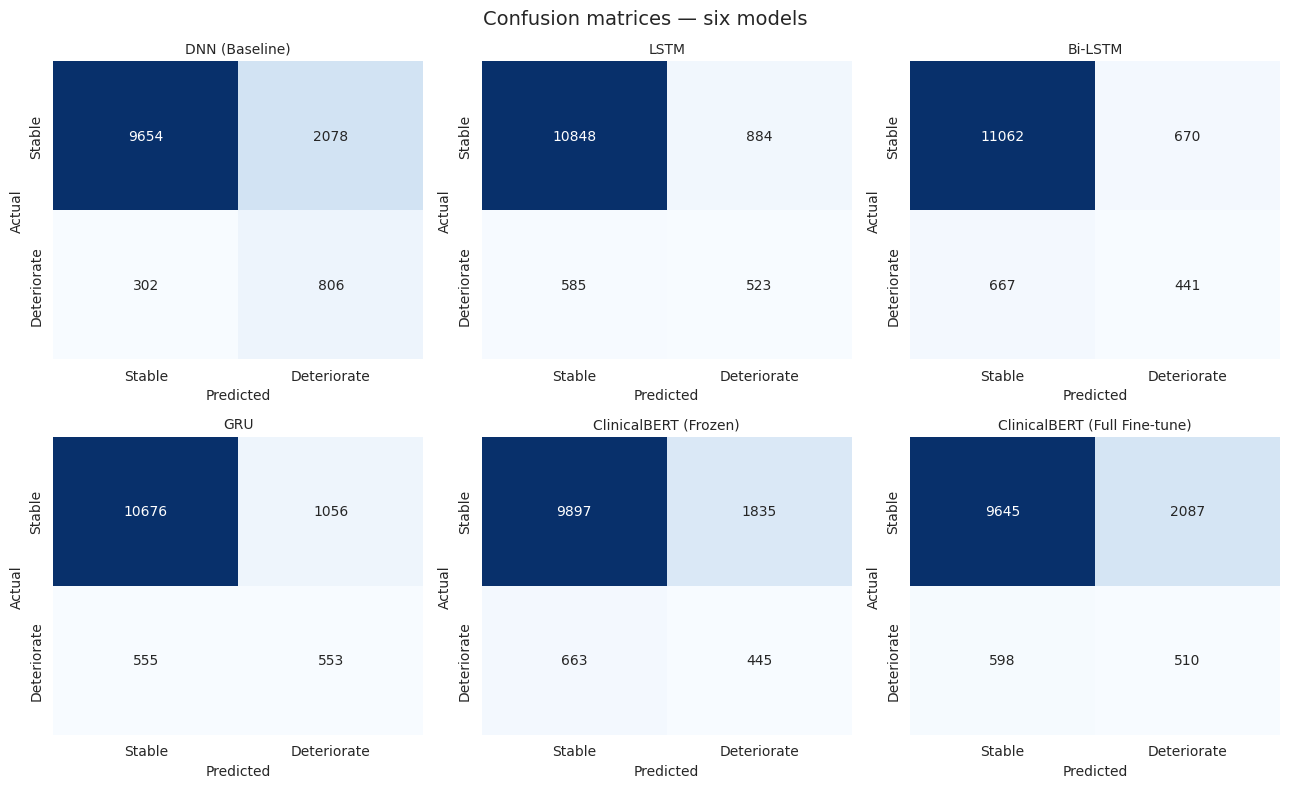

In [ ]:
# Confusion matrices, all six side by side.
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, name in zip(axes.flat, order):
    cm = confusion_matrix(yte, RESULTS[name]["pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Stable","Deteriorate"], yticklabels=["Stable","Deteriorate"])
    ax.set_title(name, fontsize=10); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
fig.suptitle("Confusion matrices — six models", fontsize=14)
plt.tight_layout(); plt.show()
# In the report, read the bottom-left cell of each matrix (false negatives = missed deteriorations).
# That cell, not raw accuracy, is what decides whether a model is safe to deploy.

---
### What this notebook demonstrates
* **Gen 1** sets a floor and forces the Recall-first mindset.
* **Gen 2** shows that *sequence* beats *snapshot*, and that **bidirectionality is a deployment trap**
  for live monitoring even when it wins offline.
* **Gen 3** shows transfer learning from biomedical text, and that **full fine-tune** generally beats
  a **frozen** head once you can afford it — with attention maps giving the clinician a *why*.

See `report.pdf` for the full analysis addressed to the CMO and CTO.